# Notebook 03 - SAM Feature Extraction

This notebook extracts SAM image embeddings for the Hybrid SAM-U-Net flood-mapping pipeline.

Scope for this notebook:

- Use STURM Sentinel-2 optical imagery only.
- Use RGB bands only: B04, B03, B02.
- Create a deterministic temporary 80/10/10 split if processed outputs from Notebook 01 are not ready yet.
- Save RGB arrays and SAM embeddings in a format Notebook 04 can consume.
- Record RGB input shape and SAM embedding shape for the project report.

This notebook does not modify Notebooks 00, 01, or 02.

## Design Notes

The local STURM dataset does not appear to contain official split files. To avoid blocking Notebook 03 while Notebook 01 is still being developed, this notebook creates a reproducible temporary split using `random_state=42`:

- Train: 80%
- Validation: 10%
- Test: 10%

When Notebook 01 is finalized, Notebook 03 can be switched to read its processed RGB outputs by changing `USE_EXISTING_PROCESSED_RGB = True` and pointing `PROCESSED_RGB_ROOT` to the finalized folder.

In [28]:
from pathlib import Path
import json
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from PIL import Image
from tqdm.auto import tqdm

import torch
from segment_anything import sam_model_registry

from sklearn.model_selection import train_test_split

print("Libraries loaded")

Libraries loaded


In [30]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("CUDA device:", torch.cuda.get_device_name(0))

Device: cuda
CUDA device: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [32]:
# Paths
PROJECT_ROOT = Path(r"D:\Research\hybrid_sam\FusionSAM-Flood-Mapping")
RAW_STURM_S2_DIR = Path(r"D:\Research\flood\Dataset\Dataset\Sentinel2\S2")
RAW_STURM_MASK_DIR = Path(r"D:\Research\flood\Dataset\Dataset\Sentinel2\Floodmaps")
SAM_CHECKPOINT = Path(r"D:\Research\SEN12_flood\sam_vit_b_01ec64.pth")

# Temporary RGB outputs used until Notebook 01 is finalized.
PROCESSED_RGB_ROOT = PROJECT_ROOT / "dataset" / "processed" / "STRUM_RGB_TEMP"

# Embeddings consumed by Notebook 04.
EMBEDDING_ROOT = PROJECT_ROOT / "dataset" / "sam_embeddings" / "strum_rgb_vit_b"

# Report-friendly artifacts.
RESULTS_ROOT = PROJECT_ROOT / "results" / "notebook_03_sam_features"
SPLIT_MANIFEST_DIR = RESULTS_ROOT / "splits"

USE_EXISTING_PROCESSED_RGB = False
SAM_MODEL_TYPE = "vit_b"
SAM_INPUT_SIZE = 1024

for path in [PROCESSED_RGB_ROOT, EMBEDDING_ROOT, RESULTS_ROOT, SPLIT_MANIFEST_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw S2 dir exists:", RAW_STURM_S2_DIR.exists())
print("Raw mask dir exists:", RAW_STURM_MASK_DIR.exists())
print("SAM checkpoint exists:", SAM_CHECKPOINT.exists())

Project root: D:\Research\hybrid_sam\FusionSAM-Flood-Mapping
Raw S2 dir exists: True
Raw mask dir exists: True
SAM checkpoint exists: True


## Check for Official Split Files


In [64]:
def find_candidate_split_files(dataset_root: Path):
    patterns = ["*split*", "train*", "val*", "valid*", "test*"]
    candidates = []
    for pattern in patterns:
        candidates.extend(dataset_root.rglob(pattern))
    return sorted({p for p in candidates if p.is_file()})

DATASET_ROOT = Path(r"D:\Research\flood\Dataset\Dataset")
split_candidates = find_candidate_split_files(DATASET_ROOT)

if split_candidates:
    print("Candidate split files found:")
    for path in split_candidates:
        print("-", path)
else:
    print("No official split files found locally under:", DATASET_ROOT)

No official split files found locally under: D:\Research\flood\Dataset\Dataset


In [36]:
def collect_matched_tiles(s2_dir: Path, mask_dir: Path) -> pd.DataFrame:
    s2_files = {p.name: p for p in s2_dir.glob("*.tif")}
    mask_files = {p.name: p for p in mask_dir.glob("*.tif")}
    common_names = sorted(set(s2_files) & set(mask_files))
    missing_masks = sorted(set(s2_files) - set(mask_files))
    missing_images = sorted(set(mask_files) - set(s2_files))

    print("S2 tiles:", len(s2_files))
    print("Mask tiles:", len(mask_files))
    print("Matched tiles:", len(common_names))
    print("Missing masks:", len(missing_masks))
    print("Missing images:", len(missing_images))

    records = []
    for name in common_names:
        records.append({
            "tile_id": Path(name).stem,
            "filename": name,
            "s2_path": str(s2_files[name]),
            "mask_path": str(mask_files[name]),
        })
    return pd.DataFrame(records)

tiles_df = collect_matched_tiles(RAW_STURM_S2_DIR, RAW_STURM_MASK_DIR)
tiles_df.head()

S2 tiles: 2675
Mask tiles: 2675
Matched tiles: 2675
Missing masks: 0
Missing images: 0


,tile_id,filename,s2_path,mask_path
0,EMSR279_03ALFARO_17_16_1_1,EMSR279_03ALFARO_17_16_1_1.tif,D:\Research\flood\Dataset\Dataset\Sentinel2\S2...,D:\Research\flood\Dataset\Dataset\Sentinel2\Fl...
1,EMSR279_03ALFARO_17_16_2_1,EMSR279_03ALFARO_17_16_2_1.tif,D:\Research\flood\Dataset\Dataset\Sentinel2\S2...,D:\Research\flood\Dataset\Dataset\Sentinel2\Fl...
2,EMSR279_03ALFARO_17_16_2_2,EMSR279_03ALFARO_17_16_2_2.tif,D:\Research\flood\Dataset\Dataset\Sentinel2\S2...,D:\Research\flood\Dataset\Dataset\Sentinel2\Fl...
3,EMSR279_03ALFARO_19_18_1_2,EMSR279_03ALFARO_19_18_1_2.tif,D:\Research\flood\Dataset\Dataset\Sentinel2\S2...,D:\Research\flood\Dataset\Dataset\Sentinel2\Fl...
4,EMSR279_03ALFARO_19_18_2_2,EMSR279_03ALFARO_19_18_2_2.tif,D:\Research\flood\Dataset\Dataset\Sentinel2\S2...,D:\Research\flood\Dataset\Dataset\Sentinel2\Fl...


In [39]:
# Deterministic 80/10/10 split.
train_df, temp_df = train_test_split(
    tiles_df,
    train_size=0.80,
    random_state=SEED,
    shuffle=True,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
)

split_dfs = {
    "train": train_df.reset_index(drop=True),
    "val": val_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}

split_summary = {
    split: int(len(df)) for split, df in split_dfs.items()
}
split_summary["total"] = int(sum(split_summary.values()))
split_summary["ratios"] = {split: len(df) / len(tiles_df) for split, df in split_dfs.items()}

print(json.dumps(split_summary, indent=2))

for split, df in split_dfs.items():
    out_csv = SPLIT_MANIFEST_DIR / f"{split}_manifest.csv"
    df.to_csv(out_csv, index=False)
    print("Saved", split, "manifest:", out_csv)

with open(RESULTS_ROOT / "split_summary.json", "w", encoding="utf-8") as f:
    json.dump(split_summary, f, indent=2)

{
  "train": 2140,
  "val": 267,
  "test": 268,
  "total": 2675,
  "ratios": {
    "train": 0.8,
    "val": 0.09981308411214954,
    "test": 0.10018691588785046
  }
}
Saved train manifest: D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\results\notebook_03_sam_features\splits\train_manifest.csv
Saved val manifest: D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\results\notebook_03_sam_features\splits\val_manifest.csv
Saved test manifest: D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\results\notebook_03_sam_features\splits\test_manifest.csv


## RGB Extraction

STURM Sentinel-2 tiles are stored as 9-band stacks. In the previous implementation, RGB visualization used indices `[3, 2, 1]`, corresponding to B04, B03, B02 in the 9-band order:

`B02, B03, B04, B05, B06, B07, B08, B11, B12`

This notebook saves only RGB arrays with shape `(3, H, W)` in channel order `(Red, Green, Blue)`.

In [42]:
# Zero-based band indices in the previous 9-band STURM stack.
# rasterio uses one-based band numbers, so B04=3, B03=2, B02=1.
RGB_BAND_NUMBERS = [3, 2, 1]
RGB_BAND_NAMES = ["B04_Red", "B03_Green", "B02_Blue"]

def percentile_normalize_rgb(rgb: np.ndarray, low: float = 2, high: float = 98) -> np.ndarray:
    rgb = np.nan_to_num(rgb.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    out = np.zeros_like(rgb, dtype=np.float32)
    for c in range(rgb.shape[0]):
        lo, hi = np.percentile(rgb[c], [low, high])
        if hi <= lo:
            out[c] = 0.0
        else:
            out[c] = np.clip((rgb[c] - lo) / (hi - lo), 0.0, 1.0)
    return out


def read_sturm_rgb(s2_path: Path) -> np.ndarray:
    with rasterio.open(s2_path) as src:
        rgb = src.read(RGB_BAND_NUMBERS).astype(np.float32)
    return percentile_normalize_rgb(rgb)


def read_binary_mask(mask_path: Path) -> np.ndarray:
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    return (np.nan_to_num(mask) > 0).astype(np.float32)

sample_row = tiles_df.iloc[0]
sample_rgb = read_sturm_rgb(Path(sample_row.s2_path))
sample_mask = read_binary_mask(Path(sample_row.mask_path))

print("RGB band order:", RGB_BAND_NAMES)
print("Sample RGB shape:", sample_rgb.shape)
print("Sample RGB dtype/range:", sample_rgb.dtype, float(sample_rgb.min()), float(sample_rgb.max()))
print("Sample mask shape:", sample_mask.shape)
print("Sample mask values:", np.unique(sample_mask))

RGB band order: ['B04_Red', 'B03_Green', 'B02_Blue']
Sample RGB shape: (3, 128, 128)
Sample RGB dtype/range: float32 0.0 1.0
Sample mask shape: (128, 128)
Sample mask values: [0. 1.]


In [44]:
def save_rgb_temp_dataset(split_dfs: dict, overwrite: bool = False):
    for split, df in split_dfs.items():
        image_dir = PROCESSED_RGB_ROOT / split / "images"
        mask_dir = PROCESSED_RGB_ROOT / split / "masks"
        image_dir.mkdir(parents=True, exist_ok=True)
        mask_dir.mkdir(parents=True, exist_ok=True)

        expected_count = len(df)
        existing_images = {p.stem for p in image_dir.glob("*.npy")}
        existing_masks = {p.stem for p in mask_dir.glob("*.npy")}
        complete_ids = existing_images & existing_masks

        if len(complete_ids) == expected_count and not overwrite:
            print(f"{split}: found all {expected_count} RGB arrays and masks, skipping extraction")
            continue

        files_to_write = expected_count if overwrite else expected_count - len(complete_ids)
        print(f"{split}: {len(complete_ids)}/{expected_count} complete; writing {files_to_write} files")

        for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Saving RGB {split}"):
            tile_id = row.tile_id
            image_out = image_dir / f"{tile_id}.npy"
            mask_out = mask_dir / f"{tile_id}.npy"

            if not overwrite and image_out.exists() and mask_out.exists():
                continue

            rgb = read_sturm_rgb(Path(row.s2_path))
            mask = read_binary_mask(Path(row.mask_path))

            np.save(image_out, rgb.astype(np.float32))
            np.save(mask_out, mask.astype(np.float32))

save_rgb_temp_dataset(split_dfs, overwrite=False)


train: 2096/2140 complete; writing 44 files


Saving RGB train:   0%|          | 0/2140 [00:00<?, ?it/s]

val: 72/267 complete; writing 195 files


Saving RGB val:   0%|          | 0/267 [00:00<?, ?it/s]

test: found all 268 RGB arrays and masks, skipping extraction


In [46]:
def summarize_processed_rgb(root: Path) -> dict:
    summary = {}
    for split in ["train", "val", "test"]:
        image_dir = root / split / "images"
        mask_dir = root / split / "masks"
        image_files = sorted(image_dir.glob("*.npy"))
        mask_files = sorted(mask_dir.glob("*.npy"))
        sample_shape = None
        if image_files:
            sample_shape = tuple(np.load(image_files[0]).shape)
        summary[split] = {
            "image_count": len(image_files),
            "mask_count": len(mask_files),
            "sample_rgb_shape": sample_shape,
        }
    return summary

processed_summary = summarize_processed_rgb(PROCESSED_RGB_ROOT)
print(json.dumps(processed_summary, indent=2))

with open(RESULTS_ROOT / "processed_rgb_summary.json", "w", encoding="utf-8") as f:
    json.dump(processed_summary, f, indent=2)

{
  "train": {
    "image_count": 2140,
    "mask_count": 2140,
    "sample_rgb_shape": [
      3,
      128,
      128
    ]
  },
  "val": {
    "image_count": 267,
    "mask_count": 267,
    "sample_rgb_shape": [
      3,
      128,
      128
    ]
  },
  "test": {
    "image_count": 268,
    "mask_count": 268,
    "sample_rgb_shape": [
      3,
      128,
      128
    ]
  }
}


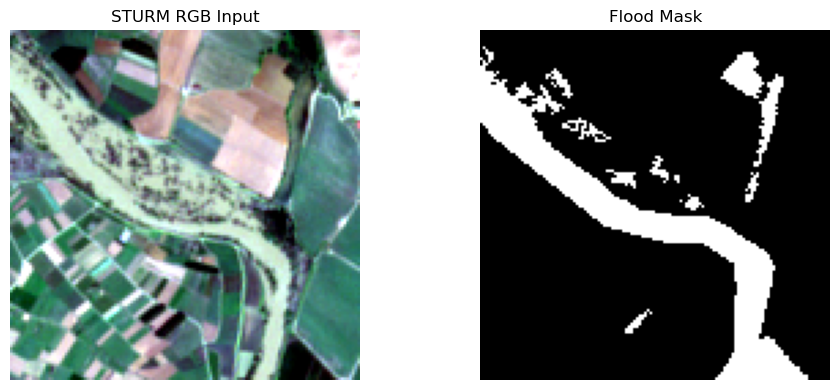

RGB input shape saved for Notebook 04: (3, 128, 128)


In [48]:
# Visual sanity check for report.
sample_file = sorted((PROCESSED_RGB_ROOT / "train" / "images").glob("*.npy"))[0]
sample_mask_file = PROCESSED_RGB_ROOT / "train" / "masks" / sample_file.name

rgb_chw = np.load(sample_file)
mask = np.load(sample_mask_file)
rgb_hwc = np.transpose(rgb_chw, (1, 2, 0))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_hwc)
plt.title("STURM RGB Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Flood Mask")
plt.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_ROOT / "rgb_mask_sample.png", dpi=200, bbox_inches="tight")
plt.show()

print("RGB input shape saved for Notebook 04:", rgb_chw.shape)

## SAM Preparation

SAM expects RGB images in `(H, W, 3)` format, usually resized to `1024 x 1024`. The saved STURM RGB arrays are `(3, 128, 128)`, so they are transposed, converted to `uint8`, resized, and passed through `sam.image_encoder`.

In [51]:
def prepare_rgb_for_sam(rgb_chw: np.ndarray, image_size: int = SAM_INPUT_SIZE) -> np.ndarray:
    rgb_chw = np.nan_to_num(rgb_chw.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    rgb_chw = np.clip(rgb_chw, 0.0, 1.0)
    rgb_hwc = np.transpose(rgb_chw, (1, 2, 0))
    rgb_uint8 = (rgb_hwc * 255.0).round().astype(np.uint8)
    pil = Image.fromarray(rgb_uint8)
    pil = pil.resize((image_size, image_size), resample=Image.BILINEAR)
    return np.array(pil, copy=True)

sam_ready = prepare_rgb_for_sam(rgb_chw)
print("Original RGB CHW shape:", rgb_chw.shape)
print("SAM-ready RGB HWC shape:", sam_ready.shape)
print("SAM-ready dtype/range:", sam_ready.dtype, int(sam_ready.min()), int(sam_ready.max()))

Original RGB CHW shape: (3, 128, 128)
SAM-ready RGB HWC shape: (1024, 1024, 3)
SAM-ready dtype/range: uint8 0 255


In [53]:
sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=str(SAM_CHECKPOINT))
sam.to(DEVICE)
sam.eval()

for parameter in sam.parameters():
    parameter.requires_grad = False

print("Loaded SAM model:", SAM_MODEL_TYPE)

Loaded SAM model: vit_b


In [54]:
def extract_sam_embedding(rgb_chw: np.ndarray) -> np.ndarray:
    sam_rgb = prepare_rgb_for_sam(rgb_chw, SAM_INPUT_SIZE)
    input_tensor = torch.from_numpy(sam_rgb).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    input_tensor = sam.preprocess(input_tensor)

    with torch.no_grad():
        embedding = sam.image_encoder(input_tensor)

    return embedding.squeeze(0).cpu().numpy().astype(np.float32)

# One-sample shape test before batch extraction.
sample_embedding = extract_sam_embedding(rgb_chw)
print("RGB input shape:", rgb_chw.shape)
print("SAM embedding shape:", sample_embedding.shape)

RGB input shape: (3, 128, 128)
SAM embedding shape: (256, 64, 64)


In [57]:
def extract_split_embeddings(split: str, overwrite: bool = False):
    image_dir = PROCESSED_RGB_ROOT / split / "images"
    save_dir = EMBEDDING_ROOT / split
    save_dir.mkdir(parents=True, exist_ok=True)

    image_files = sorted(image_dir.glob("*.npy"))
    print(f"{split}: {len(image_files)} RGB files")

    for image_file in tqdm(image_files, desc=f"SAM embeddings {split}"):
        out_file = save_dir / image_file.name
        if out_file.exists() and not overwrite:
            continue

        rgb_chw = np.load(image_file)
        embedding = extract_sam_embedding(rgb_chw)
        np.save(out_file, embedding)

    print(f"{split}: embeddings saved to {save_dir}")

# This can take time on the full dataset. Re-running is safe because existing embeddings are skipped.
for split in ["train", "val", "test"]:
    extract_split_embeddings(split, overwrite=False)

train: 2140 RGB files


SAM embeddings train:   0%|          | 0/2140 [00:00<?, ?it/s]

train: embeddings saved to D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\dataset\sam_embeddings\strum_rgb_vit_b\train
val: 267 RGB files


SAM embeddings val:   0%|          | 0/267 [00:00<?, ?it/s]

val: embeddings saved to D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\dataset\sam_embeddings\strum_rgb_vit_b\val
test: 268 RGB files


SAM embeddings test:   0%|          | 0/268 [00:00<?, ?it/s]

test: embeddings saved to D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\dataset\sam_embeddings\strum_rgb_vit_b\test


In [59]:
def summarize_embeddings(root: Path) -> dict:
    summary = {}
    for split in ["train", "val", "test"]:
        emb_dir = root / split
        files = sorted(emb_dir.glob("*.npy"))
        sample_shape = None
        if files:
            sample_shape = tuple(np.load(files[0]).shape)
        summary[split] = {
            "embedding_count": len(files),
            "sample_embedding_shape": sample_shape,
        }
    return summary

embedding_summary = summarize_embeddings(EMBEDDING_ROOT)
print(json.dumps(embedding_summary, indent=2))

notebook_03_summary = {
    "dataset": "STURM-Flood Sentinel-2 optical",
    "official_split_files_found": [str(p) for p in split_candidates],
    "split_policy": "deterministic 80/10/10 temporary split, random_state=42",
    "rgb_band_order": RGB_BAND_NAMES,
    "rgb_input_shape_chw": tuple(rgb_chw.shape),
    "sam_model_type": SAM_MODEL_TYPE,
    "sam_input_shape_hwc": tuple(sam_ready.shape),
    "sam_embedding_shape_chw": tuple(sample_embedding.shape),
    "processed_rgb_root": str(PROCESSED_RGB_ROOT),
    "embedding_root": str(EMBEDDING_ROOT),
    "split_summary": split_summary,
    "processed_summary": processed_summary,
    "embedding_summary": embedding_summary,
}

with open(RESULTS_ROOT / "notebook_03_summary.json", "w", encoding="utf-8") as f:
    json.dump(notebook_03_summary, f, indent=2)

print("Saved Notebook 03 summary:", RESULTS_ROOT / "notebook_03_summary.json")

{
  "train": {
    "embedding_count": 2140,
    "sample_embedding_shape": [
      256,
      64,
      64
    ]
  },
  "val": {
    "embedding_count": 267,
    "sample_embedding_shape": [
      256,
      64,
      64
    ]
  },
  "test": {
    "embedding_count": 268,
    "sample_embedding_shape": [
      256,
      64,
      64
    ]
  }
}
Saved Notebook 03 summary: D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\results\notebook_03_sam_features\notebook_03_summary.json


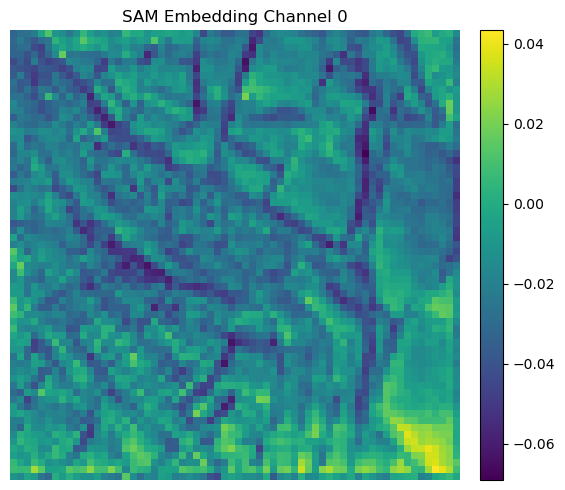

Feature map shape visualized: (256, 64, 64)


In [61]:
# Visualize one SAM feature channel for the report.
embedding_files = sorted((EMBEDDING_ROOT / "train").glob("*.npy"))
if embedding_files:
    feature = np.load(embedding_files[0])
else:
    feature = sample_embedding

plt.figure(figsize=(6, 5))
plt.imshow(feature[0], cmap="viridis")
plt.title("SAM Embedding Channel 0")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_ROOT / "sam_embedding_channel_sample.png", dpi=200, bbox_inches="tight")
plt.show()

print("Feature map shape visualized:", feature.shape)

In [68]:
print("\n" + "=" * 50)
print("FEATURE DIMENSION ANALYSIS")
print("=" * 50)

rgb_h, rgb_w = rgb_chw.shape[1], rgb_chw.shape[2]
emb_h, emb_w = feature.shape[-2], feature.shape[-1]

print(f"RGB Shape            : {rgb_chw.shape}")
print(f"SAM Embedding Shape  : {feature.shape}")

print(f"RGB Spatial Size     : {rgb_h} x {rgb_w}")
print(f"SAM Spatial Size     : {emb_h} x {emb_w}")

print(f"Downsampling Factor H: {rgb_h / emb_h:.2f}")
print(f"Downsampling Factor W: {rgb_w / emb_w:.2f}")

feature_analysis = {
    "rgb_shape": tuple(rgb_chw.shape),
    "embedding_shape": tuple(feature.shape),
    "downsample_factor_h": rgb_h / emb_h,
    "downsample_factor_w": rgb_w / emb_w,
}

print("\nFeature Analysis Summary:")
print(feature_analysis)


FEATURE DIMENSION ANALYSIS
RGB Shape            : (3, 128, 128)
SAM Embedding Shape  : (256, 64, 64)
RGB Spatial Size     : 128 x 128
SAM Spatial Size     : 64 x 64
Downsampling Factor H: 2.00
Downsampling Factor W: 2.00

Feature Analysis Summary:
{'rgb_shape': (3, 128, 128), 'embedding_shape': (256, 64, 64), 'downsample_factor_h': 2.0, 'downsample_factor_w': 2.0}


## Outputs for Notebook 04

Notebook 04 should load:

- RGB images: `PROJECT_ROOT/dataset/processed/STRUM_RGB_TEMP/{train,val,test}/images/*.npy`
- Masks: `PROJECT_ROOT/dataset/processed/STRUM_RGB_TEMP/{train,val,test}/masks/*.npy`
- SAM embeddings: `PROJECT_ROOT/dataset/sam_embeddings/strum_rgb_vit_b/{train,val,test}/*.npy`

Expected shapes:

- RGB image: `(3, 128, 128)`
- Mask: `(128, 128)` before adding channel dimension
- SAM ViT-B embedding: usually `(256, 64, 64)`

These filenames are tile IDs, so Notebook 04 can match `image`, `mask`, and `embedding` by the same `.npy` filename.